# Project T — Traffic Sign Classification via Transfer Learning
**ENGR 3110 — Intro to AI and Machine Learning**

This notebook trains a ResNet18-based transfer learning model on a traffic sign dataset.
It covers: data loading, preprocessing, train/val/test splits, model training, and evaluation.

**Dataset:** [Traffic Sign Dataset Classification](https://www.kaggle.com/datasets/ahemateja19bec1025/traffic-sign-dataset-classification) (Kaggle)  
**Approach:** Transfer learning with pretrained ResNet18 (PyTorch)  
**Task:** Multi-class image classification (up to 50 traffic sign categories)

---
> Built upon the PyTorch transfer learning tutorial:  
> https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

## 1. Install Dependencies
Uncomment and run if packages are not already installed.

In [2]:
# Uncomment lines below if running for the first time
# !pip install torch torchvision torchaudio
# !pip install kagglehub
# !pip install scikit-learn matplotlib pillow pandas numpy

## 2. Imports & Reproducibility

In [3]:
from pathlib import Path
import random
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Fix random seeds for reproducibility
SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use CPU (change to 'cuda' if GPU is available)
device = torch.device('cpu')
print('Using device:', device)
print('PyTorch version:', torch.__version__)

Using device: cpu
PyTorch version: 2.11.0


## 3. Download Dataset
Downloads from Kaggle via `kagglehub`. If running on Kaggle directly, uses the input path.

In [4]:
KAGGLE_DATASET = 'ahemateja19bec1025/traffic-sign-dataset-classification'
kaggle_input_path = Path('/kaggle/input/traffic-sign-dataset-classification')
if kaggle_input_path.exists():
    dataset_root = kaggle_input_path
    print('Using Kaggle input dataset:', dataset_root)
else:
    dataset_root = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    print('Downloaded dataset to:', dataset_root)

Downloaded dataset to: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2


## 4. Load Labels CSV

In [5]:
label_csv_candidates = list(dataset_root.rglob('labels.csv')) + list(dataset_root.rglob('*.csv'))
if not label_csv_candidates:
    raise FileNotFoundError('Could not find a CSV labels file in the dataset.')
label_csv_path = label_csv_candidates[0]
print('Using label CSV:', label_csv_path)
labels_df = pd.read_csv(label_csv_path)
print('Columns:', labels_df.columns.tolist())
print(f'Total label entries: {len(labels_df)}')
labels_df.head()

Using label CSV: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/labels.csv
Columns: ['ClassId', 'Name']
Total label entries: 58


,ClassId,Name
0,0,Speed limit (5km/h)
1,1,Speed limit (15km/h)
2,2,Speed limit (30km/h)
3,3,Speed limit (40km/h)
4,4,Speed limit (50km/h)


## 5. Define Classes — Drop Unknowns, Build Label Index

The dataset has 58 original class IDs. We drop 8 classes labeled as 'unknown'
since they provide no meaningful classification target.

We also remap the remaining class IDs to **contiguous 0-based indices**,
which is required by `nn.CrossEntropyLoss`.

In [6]:
# Class IDs identified as 'unknown' — dropped from training and evaluation
unknown_ids = {40, 41, 42, 45, 49, 52, 56, 57}

labels_clean = labels_df[~labels_df['ClassId'].isin(unknown_ids)].copy()

# Remap ClassIds to contiguous 0-based indices
valid_class_ids = sorted(labels_clean['ClassId'].unique())
class_id_to_idx = {cid: idx for idx, cid in enumerate(valid_class_ids)}
idx_to_class_id = {idx: cid for cid, idx in class_id_to_idx.items()}

label_name_lookup = dict(zip(labels_df['ClassId'], labels_df['Name']))
idx_to_name = {idx: label_name_lookup[cid] for idx, cid in idx_to_class_id.items()}

NUM_CLASSES = len(valid_class_ids)
print(f'Total valid classes (unknowns dropped): {NUM_CLASSES}')
print(f'Dropped class IDs: {sorted(unknown_ids)}')
print('\nClass index mapping:')
for idx, name in idx_to_name.items():
    print(f'  [{idx:2d}] {name}')

Total valid classes (unknowns dropped): 50
Dropped class IDs: [40, 41, 42, 45, 49, 52, 56, 57]

Class index mapping:
  [ 0] Speed limit (5km/h)
  [ 1] Speed limit (15km/h)
  [ 2] Speed limit (30km/h)
  [ 3] Speed limit (40km/h)
  [ 4] Speed limit (50km/h)
  [ 5] Speed limit (60km/h)
  [ 6] Speed limit (70km/h)
  [ 7] speed limit (80km/h)
  [ 8] Dont Go straight or left
  [ 9] Dont Go straight or Right
  [10] Dont Go straight
  [11] Dont Go Left
  [12] Dont Go Left or Right
  [13] Dont Go Right
  [14] Dont overtake from Left
  [15] No Uturn
  [16] No Car
  [17] No horn
  [18] Speed limit (40km/h)
  [19] Speed limit (50km/h)
  [20] Go straight or right
  [21] Go straight
  [22] Go Left
  [23] Go Left or right
  [24] Go Right
  [25] keep Left
  [26] keep Right
  [27] Roundabout mandatory
  [28] watch out for cars
  [29] Horn
  [30] Bicycles crossing
  [31] Uturn
  [32] Road Divider
  [33] Traffic signals
  [34] Danger Ahead
  [35] Zebra Crossing
  [36] Bicycles crossing
  [37] Children cr

## 6. Locate Image Folders

In [7]:
def find_class_folder_root(root: Path) -> Path:
    """Find the folder whose immediate subfolders are numeric class labels."""
    preferred = [
        root / 'traffic_Data' / 'DATA',
        root / 'traffic_Data',
        root / 'DATA',
        root,
    ]
    for p in preferred:
        if p.exists() and p.is_dir():
            numeric_children = [c for c in p.iterdir() if c.is_dir() and c.name.isdigit()]
            if len(numeric_children) >= 5:
                return p
    candidates = []
    for p in root.rglob('*'):
        if p.is_dir():
            numeric_children = [c for c in p.iterdir() if c.is_dir() and c.name.isdigit()]
            if len(numeric_children) >= 5:
                candidates.append((len(numeric_children), p))
    if not candidates:
        raise FileNotFoundError('Could not find a folder with numeric class subfolders.')
    candidates.sort(reverse=True)
    return candidates[0][1]

DATA_DIR = find_class_folder_root(dataset_root)
print('Using image class folder:', DATA_DIR)
print('Example class folders:', sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir() and p.name.isdigit()])[:10])

Using image class folder: /Users/thomas/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2/traffic_Data/DATA
Example class folders: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


## 7. Build Image DataFrame
One row per image, with the contiguous label index.

In [8]:
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
rows = []
for class_folder in sorted(
    [p for p in DATA_DIR.iterdir() if p.is_dir() and p.name.isdigit()],
    key=lambda p: int(p.name)
):
    original_class_id = int(class_folder.name)
    if original_class_id in unknown_ids:
        continue
    if original_class_id not in class_id_to_idx:
        continue
    label_idx = class_id_to_idx[original_class_id]
    for img_path in class_folder.rglob('*'):
        if img_path.suffix.lower() in image_extensions:
            rows.append({
                'image_path': str(img_path),
                'ClassId':    original_class_id,
                'LabelIdx':   label_idx,
                'Name':       label_name_lookup.get(original_class_id, 'Unknown'),
            })

image_df = pd.DataFrame(rows)
if image_df.empty:
    raise ValueError('No images found. Check DATA_DIR and dataset structure.')

print(f'Total usable images after dropping unknowns: {len(image_df)}')
print('Unknown rows remaining:', image_df['ClassId'].isin(unknown_ids).sum())
print('\nPer-class image counts:')
print(image_df.groupby(['ClassId','Name'])['image_path'].count().rename('count').to_string())

Total usable images after dropping unknowns: 3870
Unknown rows remaining: 0

Per-class image counts:
ClassId  Name                        
0        Speed limit (5km/h)             118
1        Speed limit (15km/h)             40
2        Speed limit (30km/h)             80
3        Speed limit (40km/h)            260
4        Speed limit (50km/h)             98
5        Speed limit (60km/h)            194
6        Speed limit (70km/h)             78
7        speed limit (80km/h)            152
8        Dont Go straight or left          8
9        Dont Go straight or Right         2
10       Dont Go straight                 70
11       Dont Go Left                    138
12       Dont Go Left or Right            96
13       Dont Go Right                    36
14       Dont overtake from Left         128
15       No Uturn                         22
16       No Car                          142
17       No horn                         130
18       Speed limit (40km/h)              8
19    

## 8. Train / Validation / Test Split (70% / 15% / 15%)

Stratified splitting ensures each class is proportionally represented
in every subset. Classes with fewer than 6 images are dropped because
they cannot be reliably split into 3 stratified subsets.

In [9]:
# Drop classes with fewer than 6 images — too few for stratified splitting
class_counts = image_df['LabelIdx'].value_counts()
valid_classes = class_counts[class_counts >= 6].index
removed = class_counts[class_counts < 6]
if not removed.empty:
    print('Dropping classes with fewer than 6 images:')
    for idx, count in removed.items():
        print(f'  LabelIdx {idx} ({idx_to_name[idx]}): {count} image(s)')
image_df = image_df[image_df['LabelIdx'].isin(valid_classes)].reset_index(drop=True)
print(f'Images remaining after filter: {len(image_df)}')

image_df = image_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=SEED,
    stratify=image_df['LabelIdx'],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['LabelIdx'],
)

print(f'\nTrain images      : {len(train_df)}')
print(f'Validation images : {len(val_df)}')
print(f'Test images       : {len(test_df)}')

# Show per-class split counts
split_counts = pd.DataFrame({
    'train': train_df['Name'].value_counts(),
    'val':   val_df['Name'].value_counts(),
    'test':  test_df['Name'].value_counts(),
}).fillna(0).astype(int)
split_counts

Dropping classes with fewer than 6 images:
  LabelIdx 33 (Traffic signals): 4 image(s)
  LabelIdx 19 (Speed limit (50km/h)): 4 image(s)
  LabelIdx 9 (Dont Go straight or Right): 2 image(s)
  LabelIdx 47 (Give Way): 2 image(s)
  LabelIdx 25 (keep Left): 2 image(s)
Images remaining after filter: 3856

Train images      : 2699
Validation images : 578
Test images       : 579


,train,val,test
Name,,,
Bicycles crossing,133,28,29
Children crossing,41,9,8
Danger Ahead,18,4,4
Dangerous curve to the left,21,5,4
Dangerous curve to the right,24,5,5
Dont Go Left,96,21,21
Dont Go Left or Right,67,14,15
Dont Go Right,25,6,5
Dont Go straight,49,10,11


## 9. Dataset Class & DataLoaders

Training uses data augmentation (rotation, color jitter, affine) to improve generalization.
Validation and test use only resizing and normalization.
All images are normalized using ImageNet mean/std since we use pretrained ImageNet weights.

In [10]:
class TrafficSignDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row   = self.dataframe.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['LabelIdx'])  # contiguous 0-based index
        if self.transform is not None:
            image = self.transform(image)
        return image, label


IMG_SIZE      = 224
BATCH_SIZE    = 32
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Training: augmented
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Validation / Test: no augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = TrafficSignDataset(train_df, transform=train_transform)
val_dataset   = TrafficSignDataset(val_df,   transform=val_test_transform)
test_dataset  = TrafficSignDataset(test_df,  transform=val_test_transform)

num_workers  = 0  # CPU-only; increase if using GPU
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
print('Dataloaders ready.')

Dataloaders ready.


## 10. Sanity Check — Visualise a Training Batch

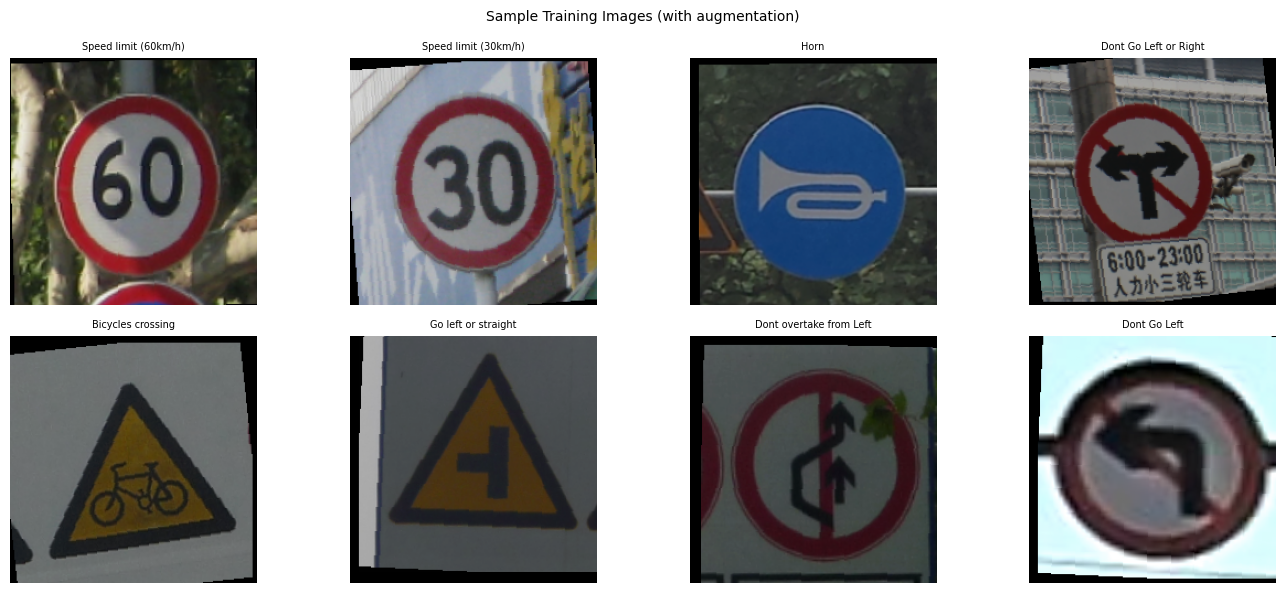

In [11]:
def denormalize(tensor):
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std  = torch.tensor(imagenet_std).view(3, 1, 1)
    return tensor * std + mean

images, labels = next(iter(train_loader))
plt.figure(figsize=(14, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1)
    plt.imshow(img)
    plt.title(idx_to_name[int(labels[i])], fontsize=7)
    plt.axis('off')
plt.suptitle('Sample Training Images (with augmentation)', fontsize=10)
plt.tight_layout()
plt.show()

## 11. Model — Pretrained ResNet18 (Transfer Learning)

We use ResNet18 pretrained on ImageNet.
- All layers are **frozen** (weights not updated during training)
- The **last ResNet block (layer4)** is unfrozen to allow fine-tuning
- The **final classification head** is replaced with a new linear layer
  outputting `NUM_CLASSES` logits

This approach (transfer learning) lets us leverage powerful visual features
learned from millions of ImageNet images without training from scratch.

In [12]:
try:
    weights = models.ResNet18_Weights.DEFAULT
    model   = models.resnet18(weights=weights)
    print('Loaded pretrained ResNet18 ImageNet weights.')
except Exception as e:
    print('Could not load pretrained weights. Using random init. Reason:', e)
    model = models.resnet18(weights=None)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last ResNet block for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier head with one suited to our number of classes
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.30),           # reduces overfitting
    nn.Linear(in_features, NUM_CLASSES)
)
model = model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())
print(f'Output classes    : {NUM_CLASSES}')
print(f'Trainable params  : {trainable_params:,} / {total_params:,} total')

Loaded pretrained ResNet18 ImageNet weights.
Output classes    : 50
Trainable params  : 8,419,378 / 11,202,162 total


## 12. Loss, Optimizer & Learning Rate Scheduler

In [13]:
# CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss()

# Only pass parameters that require gradients to the optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# Reduce LR by half if val loss doesn't improve for 2 consecutive epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)
print('Criterion, optimizer, and scheduler defined.')

Criterion, optimizer, and scheduler defined.


## 13. Training Loop

Trains for `num_epochs` epochs. After each epoch:
- Validation loss and accuracy are computed
- The LR scheduler checks for plateau
- Best model weights (lowest val loss) are saved and restored at the end

In [14]:
num_epochs = 10
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

best_val_loss    = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    # ── Training phase ────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    correct = total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # ── Validation phase ──────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc  = correct / total

    scheduler.step(val_loss)

    # Save best weights
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1:02d}/{num_epochs} | '
          f'Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | '
          f'Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}')

# Restore best model weights before evaluation
model.load_state_dict(best_model_state)
print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')

Epoch 01/10 | Train loss: 0.6811 | Train acc: 0.8336 | Val loss: 0.1363 | Val acc: 0.9585
Epoch 02/10 | Train loss: 0.1162 | Train acc: 0.9715 | Val loss: 0.0802 | Val acc: 0.9758
Epoch 03/10 | Train loss: 0.0763 | Train acc: 0.9767 | Val loss: 0.0471 | Val acc: 0.9740
Epoch 04/10 | Train loss: 0.0468 | Train acc: 0.9878 | Val loss: 0.0524 | Val acc: 0.9862
Epoch 05/10 | Train loss: 0.0578 | Train acc: 0.9859 | Val loss: 0.1377 | Val acc: 0.9637
Epoch 06/10 | Train loss: 0.0379 | Train acc: 0.9900 | Val loss: 0.0062 | Val acc: 1.0000
Epoch 07/10 | Train loss: 0.0065 | Train acc: 0.9981 | Val loss: 0.0028 | Val acc: 0.9983
Epoch 08/10 | Train loss: 0.0044 | Train acc: 0.9989 | Val loss: 0.0087 | Val acc: 0.9983
Epoch 09/10 | Train loss: 0.0078 | Train acc: 0.9978 | Val loss: 0.0099 | Val acc: 0.9983
Epoch 10/10 | Train loss: 0.0390 | Train acc: 0.9915 | Val loss: 0.0114 | Val acc: 0.9983

Training complete. Best val loss: 0.0028


## 14. Training Curves

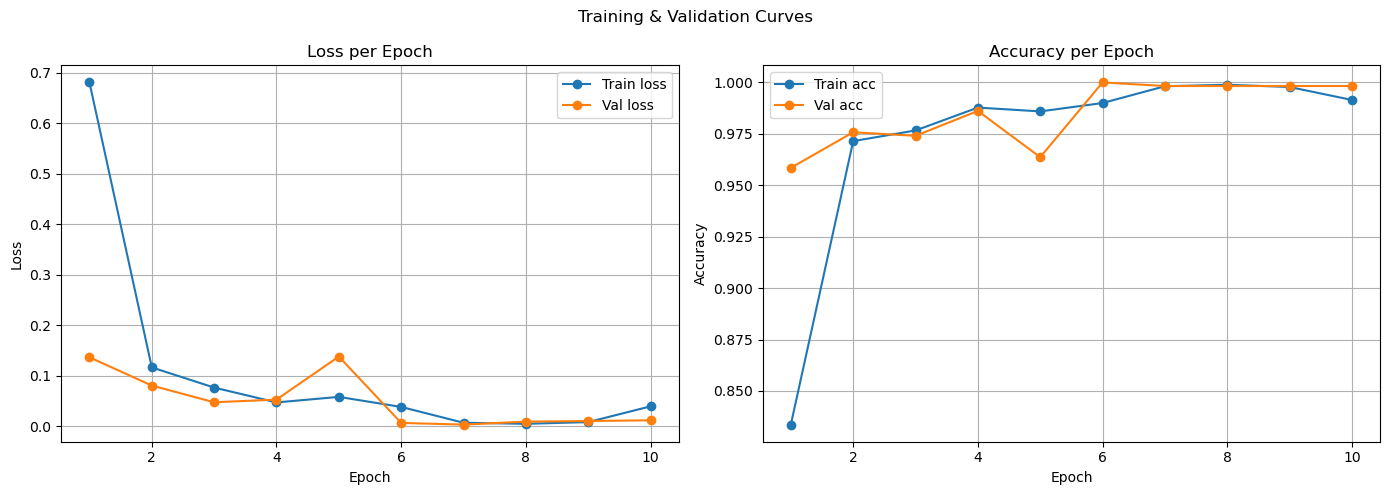

In [15]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label='Train loss', marker='o')
axes[0].plot(epochs, val_losses,   label='Val loss',   marker='o')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_accs, label='Train acc', marker='o')
axes[1].plot(epochs, val_accs,   label='Val acc',   marker='o')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training & Validation Curves', fontsize=12)
plt.tight_layout()
plt.show()

## 15. Test Set Evaluation
Evaluates the best model on the held-out test set (15% of the dataset).

In [19]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n')

# Per-class precision, recall, F1
present_indices = sorted(set(all_labels))
present_names   = [idx_to_name[i] for i in present_indices]
print(classification_report(all_labels, all_preds, labels=present_indices, target_names=present_names))

Test Accuracy: 0.9965 (99.65%)

                              precision    recall  f1-score   support

         Speed limit (5km/h)       1.00      1.00      1.00        18
        Speed limit (15km/h)       1.00      1.00      1.00         6
        Speed limit (30km/h)       1.00      1.00      1.00        12
        Speed limit (40km/h)       1.00      1.00      1.00        39
        Speed limit (50km/h)       1.00      1.00      1.00        15
        Speed limit (60km/h)       1.00      1.00      1.00        29
        Speed limit (70km/h)       1.00      1.00      1.00        12
        speed limit (80km/h)       1.00      1.00      1.00        23
    Dont Go straight or left       0.50      1.00      0.67         1
            Dont Go straight       1.00      1.00      1.00        11
                Dont Go Left       1.00      1.00      1.00        21
       Dont Go Left or Right       1.00      1.00      1.00        15
               Dont Go Right       1.00      1.00      1.

## 16. Confusion Matrix

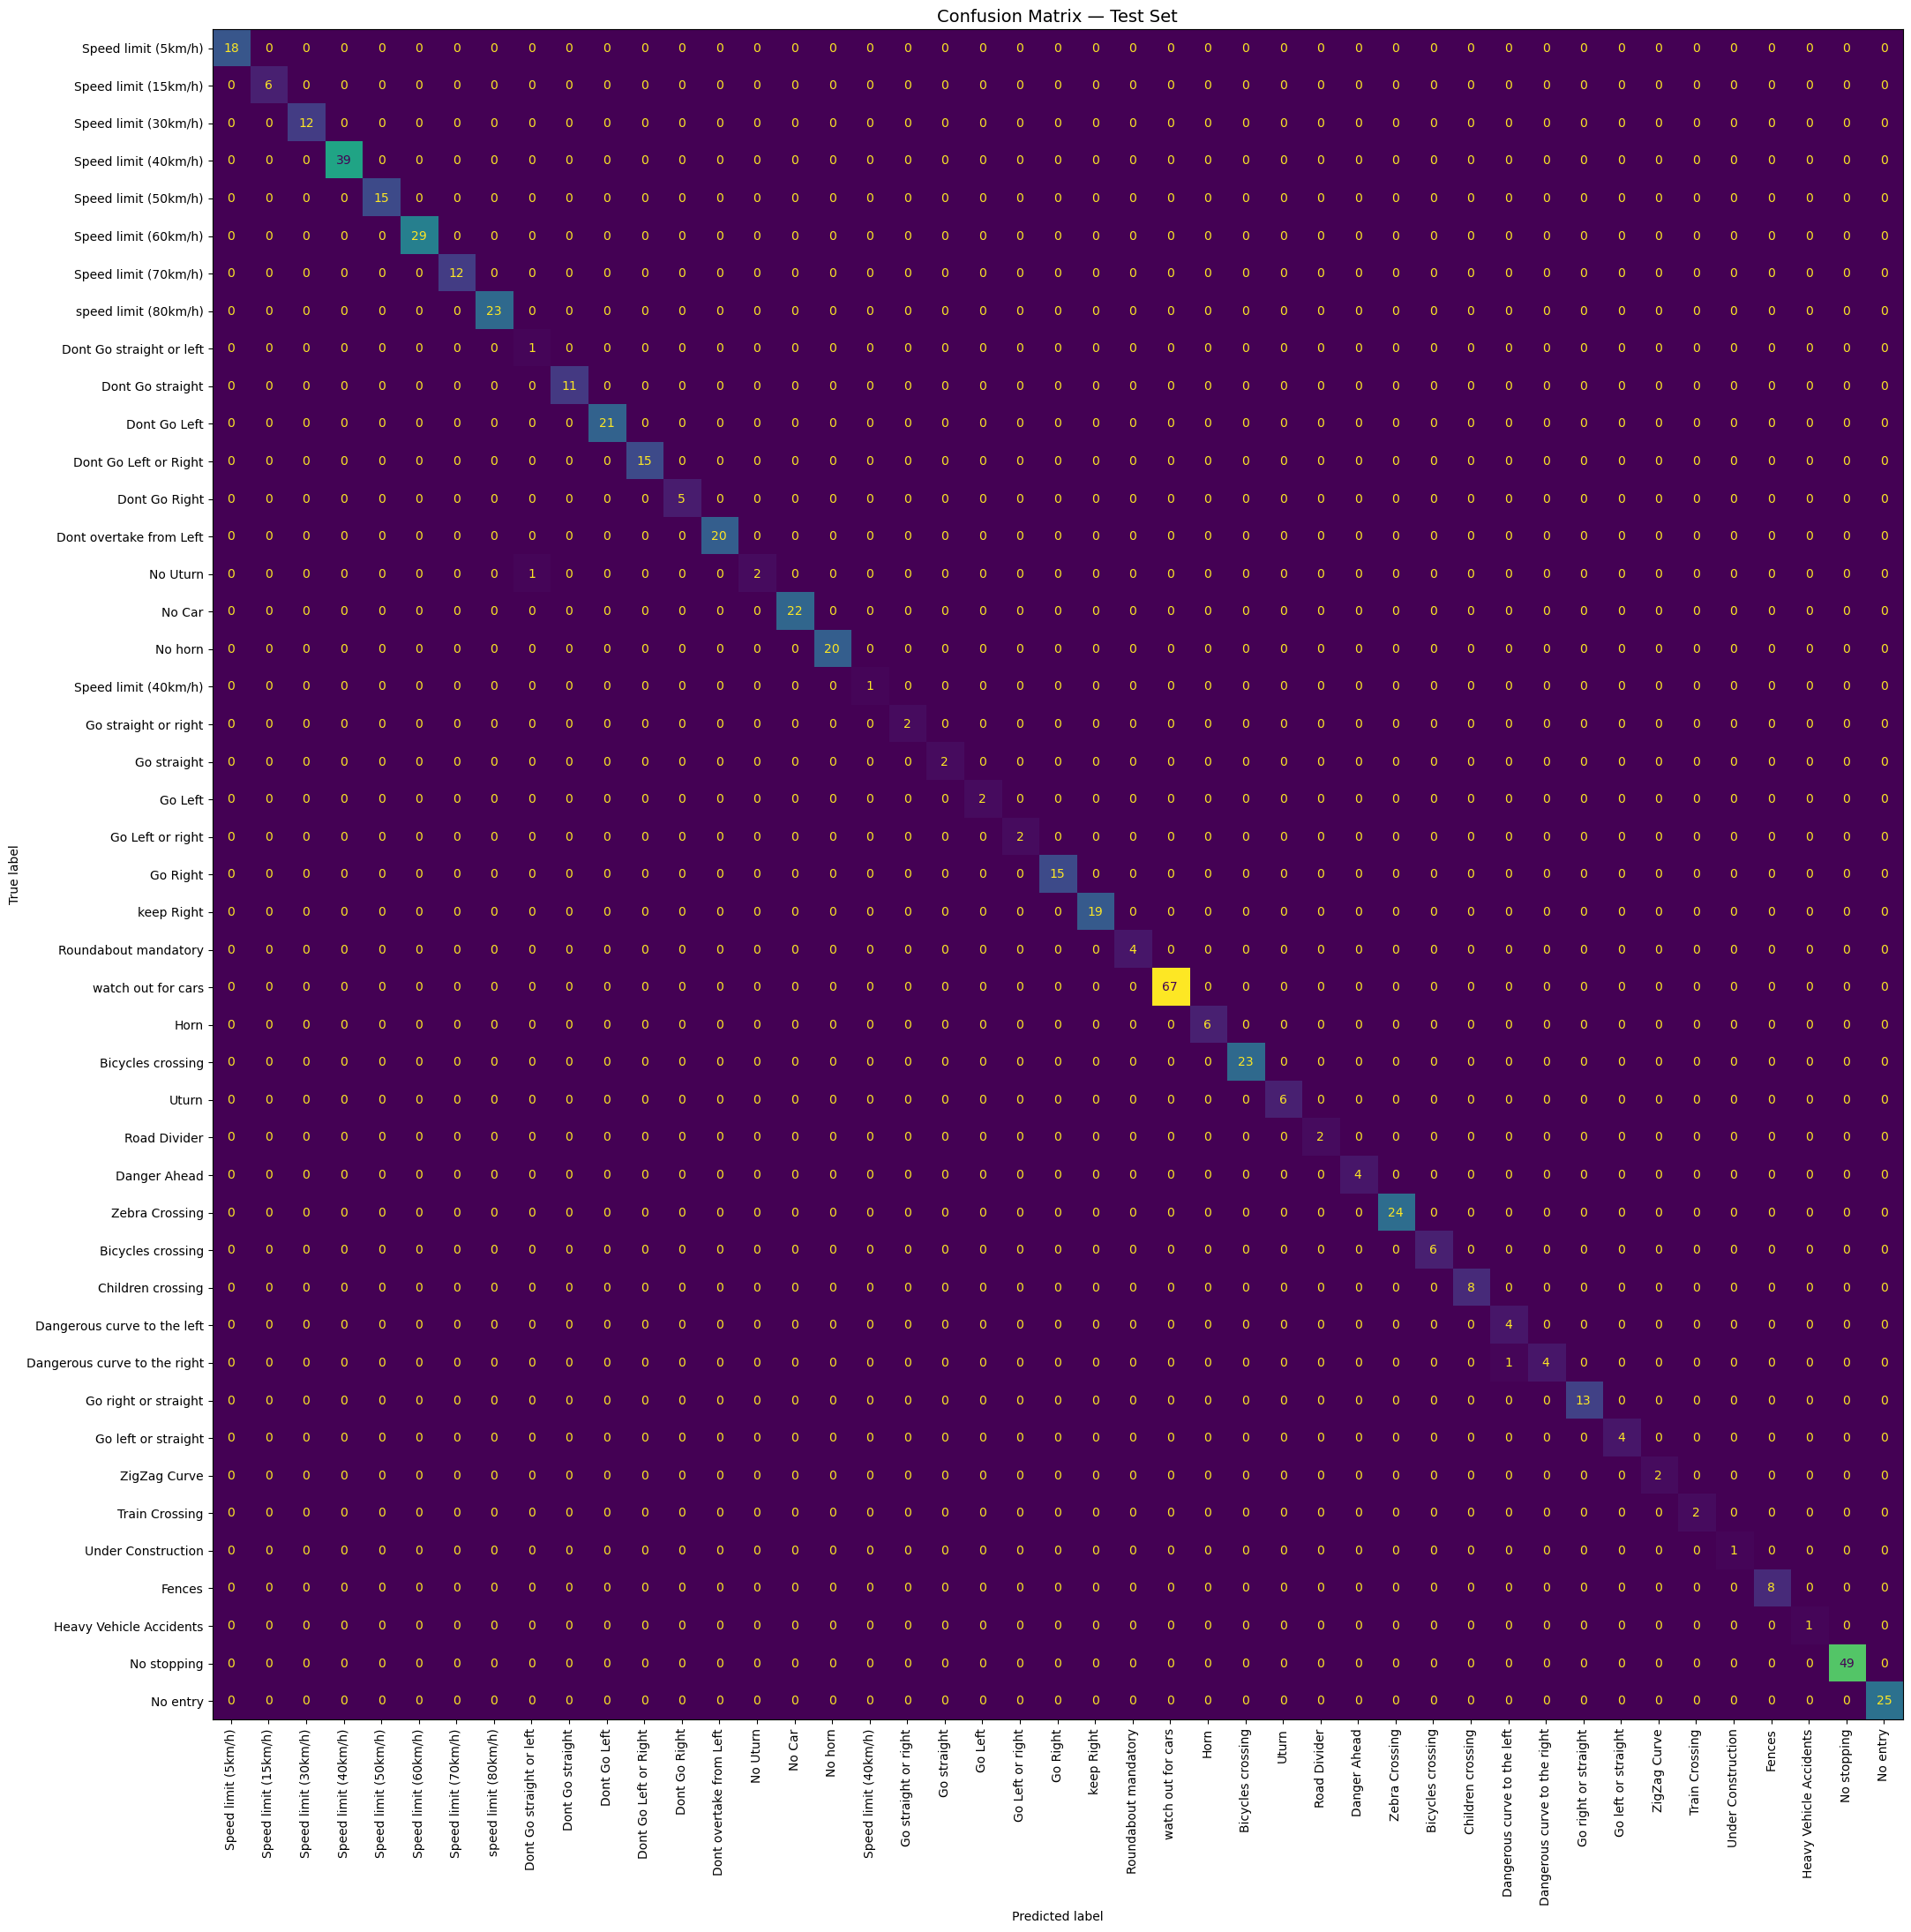

In [20]:
cm = confusion_matrix(all_labels, all_preds, labels=present_indices)
fig, ax = plt.subplots(figsize=(22, 22))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_names)
disp.plot(ax=ax, xticks_rotation='vertical', colorbar=False)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

## 17. Save Trained Model

Saves the model weights and label mappings to a `.pth` file.
This file is loaded by the demo notebook — **no retraining needed**.

In [22]:
save_path = 'traffic_sign_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_id_to_idx':  class_id_to_idx,
    'idx_to_class_id':  idx_to_class_id,
    'idx_to_name':      idx_to_name,
    'num_classes':      NUM_CLASSES,
}, save_path)
print(f'Model saved to: {save_path}')
print('Load this file in the demo notebook to classify new images without retraining.')

Model saved to: traffic_sign_model.pth
Load this file in the demo notebook to classify new images without retraining.
